# 🏦 Credit Risk Analyzer — SHAP Explainability
## Home Credit Default Risk Dataset
- **Goal:** Explain XGBoost model predictions using SHAP values
- **Model:** XGBoost (ROC-AUC: 0.7601)
- **Explainer:** TreeExplainer — optimized for tree-based models
- **Output:** Global feature importance + Local prediction explanations

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# SHAP
import shap

# Model loading
import joblib

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load saved XGBoost model and processed test data
xgb_model = joblib.load('../models/xgb_model.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')

# Load test data for SHAP analysis
test_df = pd.read_csv('../data/processed/test_processed.csv')

X_test = test_df.drop('TARGET', axis=1)
y_test = test_df['TARGET']

print(f"Model loaded: {type(xgb_model)}")
print(f"Test data shape: {X_test.shape}")
print(f"Feature columns: {len(feature_columns)}")
print("✅ Model and data loaded!")

Model loaded: <class 'xgboost.sklearn.XGBClassifier'>
Test data shape: (61503, 232)
Feature columns: 232
✅ Model and data loaded!


In [3]:
# Initialize SHAP TreeExplainer
# TreeExplainer is optimized for tree-based models like XGBoost

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
# Using sample of 5000 rows — full 61K rows will be very slow and may cause memory issues
print("Calculating SHAP values (sample of 5000 rows)...")
X_sample = X_test.sample(5000, random_state=42)

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base): {explainer.expected_value:.4f}")
print("✅ SHAP values calculated!")

Initializing SHAP TreeExplainer...
Calculating SHAP values (sample of 5000 rows)...
SHAP values shape: (5000, 232)
Expected value (base): 0.0349
✅ SHAP values calculated!


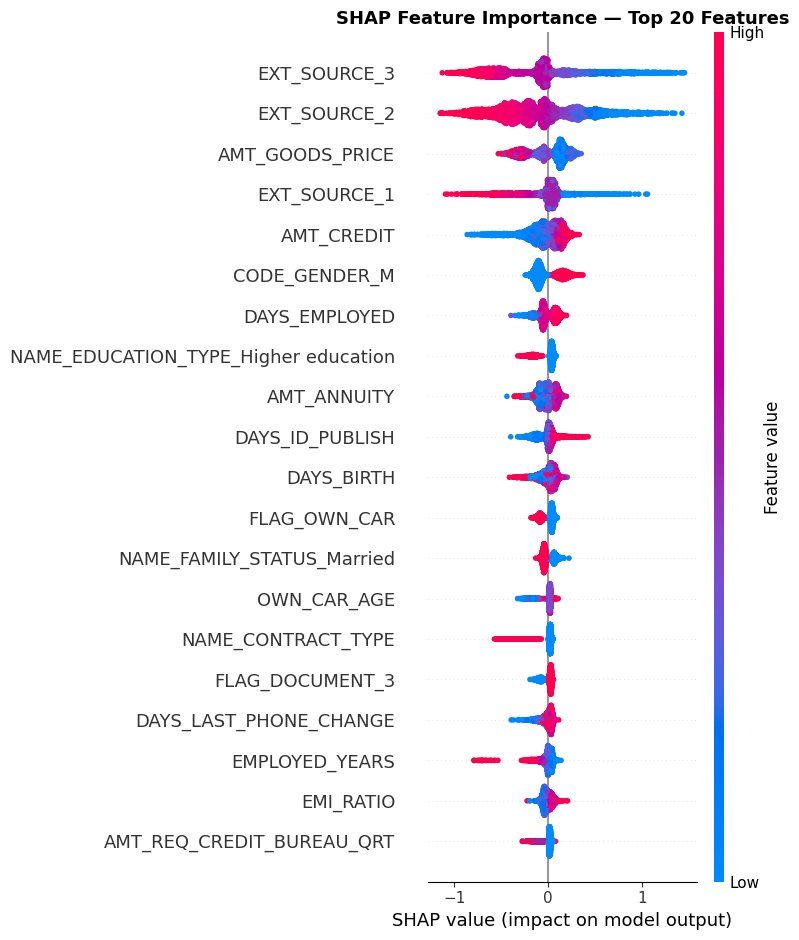

✅ Global SHAP summary plot done!


In [4]:
# Global Feature Importance — SHAP Summary Plot
# Shows which features impact the model most overall

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample,
    max_display=20,      # Show top 20 features 
    show=False
)
plt.title('SHAP Feature Importance — Top 20 Features', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Global SHAP summary plot done!")

### 📊 Global SHAP Analysis — Top 20 Features

The SHAP summary plot confirms that the model learned meaningful patterns:

- `EXT_SOURCE_3/2/1` — strongest predictors, high credit score reduces default risk significantly
- `EMPLOYED_YEARS` — longer employment = lower risk, aligns with rule engine logic
- `EMI_RATIO` — high EMI ratio increases risk, directly maps to our rule engine
- `CODE_GENDER_M` — males carry slightly higher risk (consistent with EDA findings)
- `DAYS_BIRTH` — older applicants = lower risk
- `NAME_EDUCATION_TYPE_Higher education` — educated applicants = lower risk

All findings are consistent with EDA analysis — model learned real-world patterns.